## Data Preprocessing and Statistical Analysis Using Python

## A. Data Cleaning

**1.** Create a DataFrame with missing values. Write a Python program to:
    a) Identify missing values
    b) Replace them with mean/median values.

In [17]:
import pandas as pd
import numpy as np
data = {'Name':['Krishna', 'Nischal', 'Mahim', 'A','B','Mahim', 'D', 'E', 'F'], 'Age':[20,np.nan,21,20,np.nan,21,30,50,14], 'city':['Delhi', 'Bengaluru', 'Gwalior', 'Delhi', 'Bengaluru', 'Gwalior', 'Noida', 'Bengaluru', 'Bareilly']}
df = pd.DataFrame(data)
print(df)

      Name   Age       city
0  Krishna  20.0      Delhi
1  Nischal   NaN  Bengaluru
2    Mahim  21.0    Gwalior
3        A  20.0      Delhi
4        B   NaN  Bengaluru
5    Mahim  21.0    Gwalior
6        D  30.0      Noida
7        E  50.0  Bengaluru
8        F  14.0   Bareilly


In [15]:
df.isnull().sum()

,0
Name,0
Age,2
city,0


In [18]:
#df['Age'].fillna(df['Age'].mean(), inplace=True)
#Warning :
# when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.

df['Age'] = df['Age'].fillna(df['Age'].mean())
df

,Name,Age,city
0,Krishna,20.000000,Delhi
1,Nischal,25.142857,Bengaluru
2,Mahim,21.000000,Gwalior
3,A,20.000000,Delhi
4,B,25.142857,Bengaluru
5,Mahim,21.000000,Gwalior
6,D,30.000000,Noida
7,E,50.000000,Bengaluru
8,F,14.000000,Bareilly


**2.** Write a program to remove duplicate rows from a dataset and display the cleaned dataset.

In [19]:
df.drop_duplicates(inplace=True)
df

,Name,Age,city
0,Krishna,20.000000,Delhi
1,Nischal,25.142857,Bengaluru
2,Mahim,21.000000,Gwalior
3,A,20.000000,Delhi
4,B,25.142857,Bengaluru
6,D,30.000000,Noida
7,E,50.000000,Bengaluru
8,F,14.000000,Bareilly


**3.** Create a dataset containing outliers. Detect outliers using the IQR method and remove them.

In [55]:
import pandas as pd
import numpy as np
data = {'Name':['Krishna', 'Nischal', 'Mahim', 'A','B','Mahim', 'D', 'E', 'F'], 'Age':[20,1000,21,20,5,10,300,50,14], 'city':['Delhi', 'Bengaluru', 'Gwalior', 'Delhi', 'Bengaluru', 'Gwalior', 'Noida', 'Bengaluru', 'Bareilly']}
df = pd.DataFrame(data)
print(df)

      Name   Age       city
0  Krishna    20      Delhi
1  Nischal  1000  Bengaluru
2    Mahim    21    Gwalior
3        A    20      Delhi
4        B     5  Bengaluru
5    Mahim    10    Gwalior
6        D   300      Noida
7        E    50  Bengaluru
8        F    14   Bareilly


In [56]:
df.describe()

,Age
count,9.000000
mean,160.000000
std,328.569247
min,5.000000
25%,14.000000
50%,20.000000
75%,50.000000
max,1000.000000


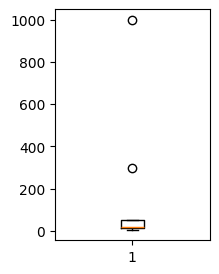

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,3))
plt.boxplot(df['Age'])
plt.show()

In [59]:
iqr = df['Age'].quantile(0.75) - df['Age'].quantile(0.25)
lower_bound = df['Age'].quantile(0.25) - 1.5 * iqr
upper_bound = df['Age'].quantile(0.75) + 1.5 * iqr
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]
print(upper_bound)
print(lower_bound)
df

33.25
-0.75


,Name,Age,city
0,Krishna,20,Delhi
2,Mahim,21,Gwalior
3,A,20,Delhi
4,B,5,Bengaluru
5,Mahim,10,Gwalior
8,F,14,Bareilly


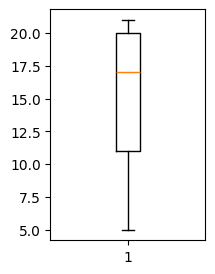

In [60]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,3))
plt.boxplot(df['Age'])
plt.show()

**4.** Write a Python program to standardize inconsistent text data (e.g., “Male”, “male”, “M”, “m” → “Male”).

In [64]:
data = {'Name':['Krishna', 'Nischal', 'Mahim', 'A','B','Mahim', 'D', 'E', 'F'], 'Age':[20,'10',21,'20',5,10,300,50,14], 'city':['Delhi', 'Bengaluru', 'Gwalior', 'Delhi', 'Bengaluru', 'Gwalior', 'Noida', 'Bengaluru', 'Bareilly'], 'Gender': ['M',"male",'Male','M',"male",'Male','M',"male",'Male']}
df2 = pd.DataFrame(data)
df2

,Name,Age,city,Gender
0,Krishna,20,Delhi,M
1,Nischal,10,Bengaluru,male
2,Mahim,21,Gwalior,Male
3,A,20,Delhi,M
4,B,5,Bengaluru,male
5,Mahim,10,Gwalior,Male
6,D,300,Noida,M
7,E,50,Bengaluru,male
8,F,14,Bareilly,Male


In [65]:
df2['Gender'] = df2['Gender'].str.lower()
df2['Gender'] = df2['Gender'].replace({'m':'male'})
df2

,Name,Age,city,Gender
0,Krishna,20,Delhi,male
1,Nischal,10,Bengaluru,male
2,Mahim,21,Gwalior,male
3,A,20,Delhi,male
4,B,5,Bengaluru,male
5,Mahim,10,Gwalior,male
6,D,300,Noida,male
7,E,50,Bengaluru,male
8,F,14,Bareilly,male


**5.** Given a dataset with incorrect data types (e.g., age stored as string), write a program to convert columns to appropriate data types.

In [66]:
df2['Age'] = df2['Age'].astype(int)
df2.dtypes

,0
Name,object
Age,int64
city,object
Gender,object


## B. Data Integration

**6.** Create two DataFrames containing student details and marks. Merge them using a common column (Student_ID).

In [67]:
df_1 = pd.DataFrame({'Student_ID':[1,2,3,4,5,6,7,8,9,10], 'Subject':['A','B','C','D','E','F','G','H','I','J'], 'Marks':[10,20,30,40,50,60,70,80,90,100]})
df_2 = pd.DataFrame({'Student_ID':[1,2,3,4,5], 'Subject':['A','B','C','D','E'], 'Marks':[60,70,80,90,100]})
print(df_1)
print(df_2)

   Student_ID Subject  Marks
0           1       A     10
1           2       B     20
2           3       C     30
3           4       D     40
4           5       E     50
5           6       F     60
6           7       G     70
7           8       H     80
8           9       I     90
9          10       J    100
   Student_ID Subject  Marks
0           1       A     60
1           2       B     70
2           3       C     80
3           4       D     90
4           5       E    100


In [68]:
df_3 = pd.merge(df_1, df_2, on='Student_ID')
df_3

,Student_ID,Subject_x,Marks_x,Subject_y,Marks_y
0,1,A,10,A,60
1,2,B,20,B,70
2,3,C,30,C,80
3,4,D,40,D,90
4,5,E,50,E,100


**7.** Write a program to concatenate two datasets vertically and horizontally.

In [69]:
df_4 = pd.concat([df_1, df_2], axis=0)
df_4

,Student_ID,Subject,Marks
0,1,A,10
1,2,B,20
2,3,C,30
3,4,D,40
4,5,E,50
5,6,F,60
6,7,G,70
7,8,H,80
8,9,I,90
9,10,J,100


In [70]:
df_5 = pd.concat([df_1, df_2], axis=1)
df_5

,Student_ID,Subject,Marks,Student_ID,Subject,Marks
0,1,A,10,1.0,A,60.0
1,2,B,20,2.0,B,70.0
2,3,C,30,3.0,C,80.0
3,4,D,40,4.0,D,90.0
4,5,E,50,5.0,E,100.0
5,6,F,60,NaN,NaN,NaN
6,7,G,70,NaN,NaN,NaN
7,8,H,80,NaN,NaN,NaN
8,9,I,90,NaN,NaN,NaN
9,10,J,100,NaN,NaN,NaN


**8.** Perform inner join, left join, and right join on two DataFrames and compare the outputs.

In [73]:
df_6 = pd.merge(df_1, df_2, on='Student_ID', how='inner')
df_6

,Student_ID,Subject_x,Marks_x,Subject_y,Marks_y
0,1,A,10,A,60
1,2,B,20,B,70
2,3,C,30,C,80
3,4,D,40,D,90
4,5,E,50,E,100


In [72]:
df_7 = pd.merge(df_1, df_2, on='Student_ID', how='left')
df_7

,Student_ID,Subject_x,Marks_x,Subject_y,Marks_y
0,1,A,10,A,60.0
1,2,B,20,B,70.0
2,3,C,30,C,80.0
3,4,D,40,D,90.0
4,5,E,50,E,100.0
5,6,F,60,NaN,NaN
6,7,G,70,NaN,NaN
7,8,H,80,NaN,NaN
8,9,I,90,NaN,NaN
9,10,J,100,NaN,NaN


In [71]:
df_8 = pd.merge(df_1, df_2, on='Student_ID', how='right')
df_8

,Student_ID,Subject_x,Marks_x,Subject_y,Marks_y
0,1,A,10,A,60
1,2,B,20,B,70
2,3,C,30,C,80
3,4,D,40,D,90
4,5,E,50,E,100


**9.** Integrate two datasets where column names are different but represent the same attribute.

In [83]:
df11 = pd.DataFrame({'A': ['A1', 'A1', 'A2', 'A3'],
                     'B': ['121', '345', '123', '146'],
                     'C': ['K0', 'K1', 'K0', 'K1']})

df12 = pd.DataFrame({'A': ['A1', 'A3'],
                      'BB': ['B0', 'B3'],
                      'CC': ['121', '345'],
                      'DD': ['D0', 'D1']})
print(df11)
print()
print(df12)

    A    B   C
0  A1  121  K0
1  A1  345  K1
2  A2  123  K0
3  A3  146  K1

    A  BB   CC  DD
0  A1  B0  121  D0
1  A3  B3  345  D1


In [81]:
both=pd.merge(df11,df12, how='inner',left_on=['A','B'],right_on=['A','CC'])
both

,A,B,C,BB,CC,DD
0,A1,121,K0,B0,121,D0


**10.** Combine multiple CSV files into a single DataFrame.

In [85]:
import csv
with open('file1.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'Age', 'City'])
    writer.writerow(['John', 25, 'New York'])
    writer.writerow(['Jane', 30, 'Los Angeles'])
    writer.writerow(['Bob', 35, 'Chicago'])

with open('file2.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'Age', 'City'])
    writer.writerow(['Alice', 28, 'San Francisco'])
    writer.writerow(['Eve', 32, 'Seattle'])
    writer.writerow(['Mike', 38, 'Boston'])

csv1 = pd.read_csv('file1.csv')
csv2 = pd.read_csv('file2.csv')
print(csv1)
print()
print(csv2)

   Name  Age         City
0  John   25     New York
1  Jane   30  Los Angeles
2   Bob   35      Chicago

    Name  Age           City
0  Alice   28  San Francisco
1    Eve   32        Seattle
2   Mike   38         Boston


In [86]:
df_13 = pd.concat([csv1, csv2], axis=0)
df_13

,Name,Age,City
0,John,25,New York
1,Jane,30,Los Angeles
2,Bob,35,Chicago
0,Alice,28,San Francisco
1,Eve,32,Seattle
2,Mike,38,Boston


## C. Data Transformation

**11.** Write a program to normalize a numerical column using Min-Max Normalization.

In [88]:
data = {'Name':['Krishna', 'Nischal', 'Mahim', 'A','B', 'E', 'F'], 'Age':[20,21,20,21,30,50,14], 'city':['Delhi', 'Bengaluru', 'Gwalior', 'Delhi', 'Noida', 'Bengaluru', 'Bareilly']}
df_14 = pd.DataFrame(data)
print(df_14)

      Name  Age       city
0  Krishna   20      Delhi
1  Nischal   21  Bengaluru
2    Mahim   20    Gwalior
3        A   21      Delhi
4        B   30      Noida
5        E   50  Bengaluru
6        F   14   Bareilly


In [89]:
df_14['Age'] = (df_14['Age'] - df_14['Age'].min())/(df_14['Age'].max() - df_14['Age'].min())
df_14

,Name,Age,city
0,Krishna,0.166667,Delhi
1,Nischal,0.194444,Bengaluru
2,Mahim,0.166667,Gwalior
3,A,0.194444,Delhi
4,B,0.444444,Noida
5,E,1.000000,Bengaluru
6,F,0.000000,Bareilly


**12.** Standardize a dataset using Z-score normalization.

In [105]:
data = {'Name':['Krishna', 'Nischal', 'Mahim', 'A','B', 'E', 'F'], 'Age':[20,21,20,21,30,50,14], 'city':['Delhi', 'Bengaluru', 'Gwalior', 'Delhi', 'Noida', 'Bengaluru', 'Bareilly']}
df_15 = pd.DataFrame(data)
print(df_15)

      Name  Age       city
0  Krishna   20      Delhi
1  Nischal   21  Bengaluru
2    Mahim   20    Gwalior
3        A   21      Delhi
4        B   30      Noida
5        E   50  Bengaluru
6        F   14   Bareilly


In [106]:
mean = df_15['Age'].mean()
std = df_15['Age'].std()
df_15['Age'] = (df_15['Age'] - mean)/std
df_15

,Name,Age,city
0,Krishna,-0.431362,Delhi
1,Nischal,-0.347486,Bengaluru
2,Mahim,-0.431362,Gwalior
3,A,-0.347486,Delhi
4,B,0.407397,Noida
5,E,2.084917,Bengaluru
6,F,-0.934618,Bareilly


**13.** Convert categorical data into numerical format using: One-Hot Encoding

In [108]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
ohe.fit_transform(df_14[['city']]).toarray()

array([[0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [107]:
df_15 = pd.get_dummies(df_15, columns=['city'], sparse = True)
df_15

,Name,Age,city_Bareilly,city_Bengaluru,city_Delhi,city_Gwalior,city_Noida
0,Krishna,-0.431362,False,False,True,False,False
1,Nischal,-0.347486,False,True,False,False,False
2,Mahim,-0.431362,False,False,False,True,False
3,A,-0.347486,False,False,True,False,False
4,B,0.407397,False,False,False,False,True
5,E,2.084917,False,True,False,False,False
6,F,-0.934618,True,False,False,False,False


**14.** Create bins for a continuous variable using equal-width binning.

In [123]:
data = {'Name':['Krishna', 'Nischal', 'Mahim', 'A','B', 'E', 'F'], 'Age':[20,21,20,21,30,50,14], 'city':['Delhi', 'Bengaluru', 'Gwalior', 'Delhi', 'Noida', 'Bengaluru', 'Bareilly']}
df_16 = pd.DataFrame(data)
print(df_16)

      Name  Age       city
0  Krishna   20      Delhi
1  Nischal   21  Bengaluru
2    Mahim   20    Gwalior
3        A   21      Delhi
4        B   30      Noida
5        E   50  Bengaluru
6        F   14   Bareilly


In [114]:
df_16['Category'] = pd.cut(df_16['Age'], bins=3, labels=['a','b','c'])
df_16

,Name,Age,city,Category
0,Krishna,20,Delhi,a
1,Nischal,21,Bengaluru,a
2,Mahim,20,Gwalior,a
3,A,21,Delhi,a
4,B,30,Noida,b
5,E,50,Bengaluru,c
6,F,14,Bareilly,a


**15.** Apply logarithmic transformation to a skewed dataset and compare before and after transformation.

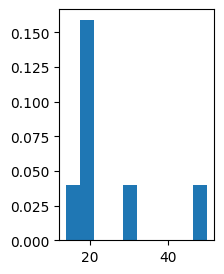

In [124]:
plt.figure(figsize=(2,3))
plt.hist(df_16['Age'], density = True)
plt.show()

In [125]:
df_16['Age'] = np.log(df_16['Age'])
df_16

,Name,Age,city
0,Krishna,2.995732,Delhi
1,Nischal,3.044522,Bengaluru
2,Mahim,2.995732,Gwalior
3,A,3.044522,Delhi
4,B,3.401197,Noida
5,E,3.912023,Bengaluru
6,F,2.639057,Bareilly


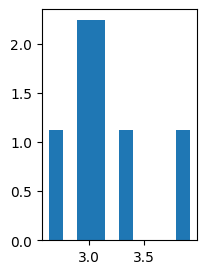

In [126]:
plt.figure(figsize=(2,3))
plt.hist(df_16['Age'], density = True)
plt.show()

## D. Correlation and Covariance

**16.** Write a program to calculate Pearson correlation coefficient between two variables.

In [127]:
df_17 = pd.DataFrame({'A': [1, 2, 3, 4, 5], 'B': [5, 7, 8, 9, 10], 'C' : [50, 40, 30,20,10]})
df_17

,A,B,C
0,1,5,50
1,2,7,40
2,3,8,30
3,4,9,20
4,5,10,10


In [133]:
print(df_17['A'].corr(df_17['B']))
print(df_17['A'].corr(df_17['C']))

0.9863939238321436
-1.0


**17.** Generate a correlation matrix for a dataset and interpret the results.

In [128]:
df_17.corr()

,A,B,C
A,1.000000,0.986394,-1.000000
B,0.986394,1.000000,-0.986394
C,-1.000000,-0.986394,1.000000


<Axes: >

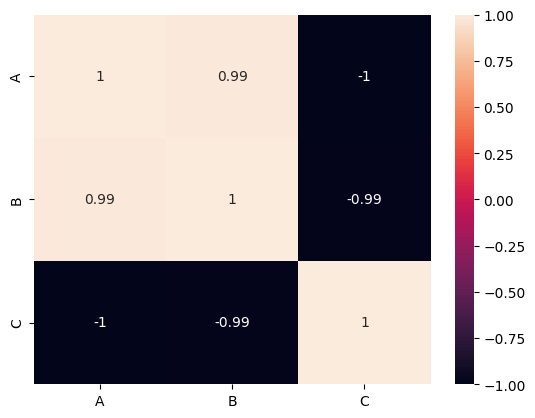

In [131]:
import seaborn as sns
sns.heatmap(df_17.corr(), annot=True)

**18.** Create two positively correlated variables and compute their correlation.

In [132]:
df_17['A'].corr(df_17['B'])

np.float64(0.9863939238321436)

**19.** Write a program to manually compute covariance (without using built-in covariance functions).

In [135]:
a = df_17['A']
b = df_17['B']
mean_a = a.mean()
mean_b = b.mean()
cov = np.sum((a - mean_a) * (b - mean_b)) / (len(a) - 1)
cov

np.float64(3.0)

**20.** Compare covariance and correlation values for the same dataset.

In [143]:
df_17.cov()

,A,B,C
A,2.5,3.0,-25.0
B,3.0,3.7,-30.0
C,-25.0,-30.0,250.0


In [142]:
df_17.corr()

,A,B,C
A,1.000000,0.986394,-1.000000
B,0.986394,1.000000,-0.986394
C,-1.000000,-0.986394,1.000000
